In [192]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


#1


In [193]:
X_fantoma = np.array([
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

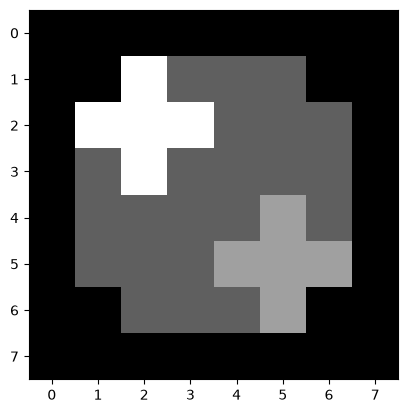

In [194]:
#A
x= plt.imshow(X_fantoma, cmap="gray")

In [195]:
#B
x_fantoma= X_fantoma.reshape(-1)
x_fantoma

array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.8, 0.3, 0.3,
       0.3, 0. , 0. , 0. , 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0. , 0. , 0.3,
       0.8, 0.3, 0.3, 0.3, 0.3, 0. , 0. , 0.3, 0.3, 0.3, 0.3, 0.5, 0.3,
       0. , 0. , 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0. , 0. , 0. , 0.3, 0.3,
       0.3, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ])

In [196]:
#C
X_temp=[]
i=0
j=0
z=0
while(i<8):
    temp = []
    while(j<8):
        temp.append(x_fantoma[z])
        j+=1
        z+=1
    j=0
    X_temp.append(temp)
    i+=1


X_fantoma_recon = np.array(X_temp,dtype=float)
X_fantoma_recon

array([[0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.8, 0.3, 0.3, 0.3, 0. , 0. ],
       [0. , 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0. ],
       [0. , 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0. ],
       [0. , 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0. ],
       [0. , 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0. ],
       [0. , 0. , 0.3, 0.3, 0.3, 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ]])

D
el valor de una compente x_k es el coeficiente de atenuidad recibida por los receptores a la hora de emitir los rayos x al realizar la tomografía, se considera una atenuidad alta (se recibe poca informacion de rayos x) a valores cercanos a 1, mientras que por el contrario se considera una atenuidad baja a los valores cercanos a 0 (se recibe en gran cantidad la informacion eviada por los rayos x), en esta imagen podemos notar como en los pixeles centrales se recibe menos información.
**escrito asi nomas, despues hay q reescribir**

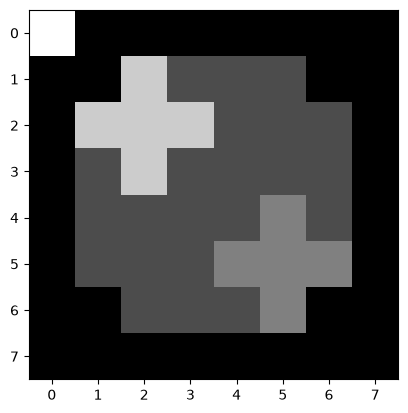

In [197]:
X_fantoma_mod = np.array([
[1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

x= plt.imshow(X_fantoma_mod, cmap="gray")


en el vector x_fantona cambia el pixel x_0
i x 8 : cuantas filas me tengo que mover desde la fila 0 para llegar a la fila donde a la que pertenece el pixel (i,j) 
j : parandome en el primer elemento de la fila a la que pertenece el pixel, a que columna me debo mover.


#2

In [198]:
#a
def mascara_rayo(n, direccion, s):
    M = np.zeros((n, n), dtype=int)
    i=0
    while(i<len(M)):
        j=0
        while j < len(M[i]):
            if direccion[0]*i + direccion[1]*j == s:
                M[i][j] = 1
            j+=1
        i+=1

    return M


In [199]:
#b
A= mascara_rayo(8,(1,0),3)
B= mascara_rayo(8,(0,1),5)
C= mascara_rayo(8,(1,1),7)
D= mascara_rayo(8,(1,-1),0)
E= mascara_rayo(8,(2,1),8)

In [200]:
A

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

In [201]:
B

array([[0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0]])

In [202]:
C

array([[0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0]])

In [203]:
D

array([[1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 1]])

In [204]:
E

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

In [205]:
def medicion_br(X_Fantoma, M_r):
    i=0
    br=0
    while(i < len(X_Fantoma)): #sabiendo que la matriz fantoma es de 8x8 al igual que M_r
        j=0
        while(j < len(X_Fantoma[0])):
            br += M_r[i][j] * X_Fantoma[i][j]
            j+=1
        j=0
        i+=1
    return br
result = medicion_br(X_fantoma, A)
result


np.float64(2.3)

## 3A y 3B

In [206]:
def matriz_proyeccion(n,direcciones):
    Matriz_resultado = [] #matriz con todos todos los rayos proyectados en filas
    lista_direccion_s = []
    for direccion in direcciones: #recorremos todas las direcciones
        res =  [] #guardamos los valores de s de cada direccion (α,β)
        i=0
        while i < n: #recorremos filas
            j=0
            while j < n: #recorremos columnas 
                s = direccion[0]*i + direccion[1]*j   #formula para calcular rayo
                res.append(s)       #guardamos los s
                j+=1
            i+=1
        valores_s = sorted(set(res))        #eliminamos los s repetidos y ordenamos de menor a mayor
        for s in valores_s:     #recorremos los s de por cada (α,β)
            lista_direccion_s.append((direccion,s))
            mascara = mascara_rayo(n, direccion, s)     #generamos la mascara del rayo generado por cada s
            proyeccion = mascara.reshape(-1)            #lo ponemos como una unica fila
            Matriz_resultado.append(proyeccion)         #agregamos a la matriz final
    return Matriz_resultado, lista_direccion_s

## 3C

In [207]:
resultado_lista = matriz_proyeccion(8, [[1,0],[0,1]])[1]
A = matriz_proyeccion(8, [[1,0],[0,1]])[0]

longitud_lista = len(resultado_lista) # miramos cuantos ((α, β), s) hay en total
longitud_matriz = (len(A), len(A[0])) #tomamos la longitud de la matriz

print("Rayos obtenidos:", longitud_lista)
print("Dimension de la matriz :", longitud_matriz)

Rayos obtenidos: 16
Dimension de la matriz : (16, 64)


## 3D



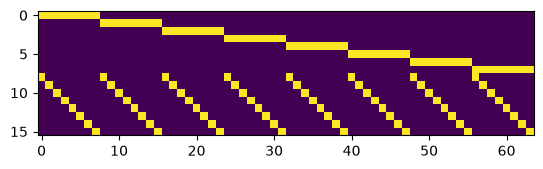

In [208]:
# cada fila representa a un rayo (su matriz de representacion aplanada en una fila)
# cada columan representa a un pixel de la imagen.
# A[r][j] = 1 si el rayo "r" pasa por el centro del pixel j.
# es logico que la matriz resultante tenga mayor cantidad de ceros, ya que solo tendra un valor distinto (1) 
# si el rayo pasa por el centro del pixel (o cambiarlo a que cada fila tiene un solo rayo entonces hay muchos ceros)
plt.imshow(A)


## 3E

In [ ]:
b = A @ x_fantoma
X_fantoma_sum_1 = X_fantoma.sum(axis=1)
X_fantoma_sum_0 = X_fantoma.sum(axis=0)

primer_comparacion = np.allclose(b[:8], X_fantoma_sum_1) 
segunda_comparacion = np.allclose(b[8:], X_fantoma_sum_0)
res = (primer_comparacion == segunda_comparacion)
res
#vemos que coinciden

True

In [ ]:
#Graficamos:
